In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
import numpy as np

import random
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt
from datetime import datetime
import copy


import lightning as pl
from lightning.pytorch.loggers import WandbLogger
import wandb
import pprint

import monai
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from kornia.losses import total_variation

from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule


from Models.models import Siren, Finer

from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_ixi import load_data, load_sensitivity_data, get_hf_observed_segmentations
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images, plot_2_images
from LFSynth.ContrastModulation import ContrastModulation


from Data.patchwise3D import RandomPointsDataset
from onnxruntime import InferenceSession
import onnx

Loading data

In [12]:
POINTS_PER_SAMPLE = 96*96*4
lf_points_per_sample = 48*48*4


config = copy.deepcopy(default_config)
config["in_features"] = 3
config["slice"] = 175
config["is_new_contrast"] = False #make this true when using new c vector
config["points_num"] = 96*96*4
config["downsampled_points"] = 48*48*4
config["hf_chunk_size"] = (96, 96, 4)
config["lf_chunk_size"] =  (48, 48, 4)

dataset_num = 102
slice_num = config["slice"]
sens_id = config["sens_id"] = 4


# hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_data(dataset_num, config) #uncomment
hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_sensitivity_data(dataset_num, config, sens_id)
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)
lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
# plt.imshow(lf_gt[:,:,slice_num], cmap='gray')
# plt.show()
print("gt_image: ", gt_image.shape, "lf_gt: ", lf_gt.shape, "lf_gt_seg_dice: ", lf_gt_seg_dice.shape)
print('gt_image, lf_gt loaded')

config["size"] = hf_ground_truth.shape
config["size_lf"] = lf_gt.shape[:-1]
config["M"] = M


(wm_obs_seg, gm_obs_seg, csf_obs_seg, bg_obs_seg) = get_hf_observed_segmentations(dataset_num, config)
hf_observed_seg_dice = torch.stack((bg_obs_seg, wm_obs_seg, gm_obs_seg, csf_obs_seg), dim=0).unsqueeze(0)
hf_observed_seg_dice.shape

[0.2922862863632516, 0.2914280646044458, 0.13082497107286503]
gt_image:  torch.Size([150, 256, 256, 1]) lf_gt:  torch.Size([75, 128, 256, 1]) lf_gt_seg_dice:  torch.Size([1, 4, 75, 128, 256])
gt_image, lf_gt loaded


torch.Size([1, 4, 150, 256, 256])

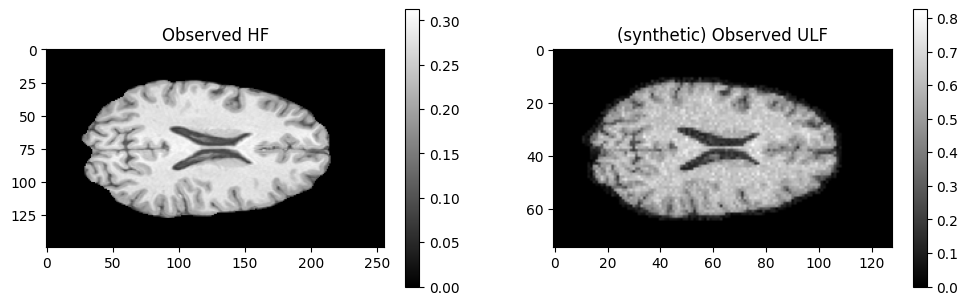

In [13]:
f_obs = plot_2_images(gt_image[:,:,slice_num],lf_gt[:,:,slice_num], title1 = "Observed HF", title2 = "(synthetic) Observed ULF", )

In [9]:
def contrast_modulation(pred_seg, pred_img, config):
    downsampled_points = config["downsampled_points"]
    M = config["M"]
    size_lf = config["size_lf"]
    pred_seg = torch.from_numpy(pred_seg)
    pred_img = torch.from_numpy(pred_img)
    imgs_list = [(F.interpolate((pred_seg[i] * pred_img).permute(2,0,1).unsqueeze(0), scale_factor=0.5).squeeze(0).permute(1,2,0)) for i in range(pred_seg.shape[0])]
    bg_img = (imgs_list[0]).reshape(size_lf)
    wm_img = (imgs_list[1]).reshape(size_lf) * M[0]
    gm_img = (imgs_list[2]).reshape(size_lf) * M[1]
    csf_img = (imgs_list[3]).reshape(size_lf) * M[2]

    lf_img = wm_img + gm_img + csf_img + bg_img
    return lf_img.numpy()

Download artifacts

In [2]:
# # To download an artifact from wandb

# import wandb
# # wandb_init = wandb.init()
# api = wandb.Api()
# run_id = "7ixybdtw" #change this every time
# entity = "pi58-sussex/"
# project = "hulfsynth/"
# run = api.run(entity + project + run_id)
# logged_artifacts = run.logged_artifacts(10)
# # print(logged_artifacts[0].name, logged_artifacts[1].name, logged_artifacts(temp)) #check number of logged artifacts in this list. usually should return two
# model_version = logged_artifacts[0].name
# print("Model version: ", model_version)
# artifact = api.artifact(entity + project +  model_version)
# artifact_dir = artifact.download()


Model version:  model:v337


wandb:   1 of 1 files downloaded.  


Inference

In [10]:
def get_session(model_loc):
    # model_temp_loc = model_loc = './saved_models/model_sens_5.1.onnx'
    onnx_model = onnx.load(model_loc)
    onnx.checker.check_model(onnx_model)

    onnx_model.graph.input[0].type.tensor_type.shape.dim[0].ClearField('dim_value')
    onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
    # onnx_model.graph.input[0].type.tensor_type.shape.dim[2].ClearField('dim_value')
    # onnx_model.graph.input[0].type.tensor_type.shape.dim[3].ClearField('dim_value')
    sess = InferenceSession(onnx_model.SerializeToString())
    return sess

def sample_at_resolution(sess):
    resolution = hf_ground_truth.shape
    meshgrid = torch.meshgrid([torch.arange(0, i, device='cpu') for i in resolution], indexing='ij')
    coords = torch.stack(meshgrid, dim=-1)
    coords_norm = coords / torch.tensor(resolution, device='cpu') * 2 - 1
    coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
    predictions_, _, pred_seg_, _ = sess.run(None, {"onnx::Gemm_0" : coords_norm_.cpu().numpy()})
    resolution_seg = list(resolution) + [pred_seg_.shape[-1]] #adding num_tissues to the resolution shape
    predictions = predictions_.reshape(resolution)
    pred_seg_ = pred_seg_.reshape(resolution_seg)
    pred_seg = [pred_seg_[:,:,:,i].reshape(resolution) for i in range(pred_seg_.shape[-1])]
    pred_seg = np.stack(pred_seg, axis = 0)
    return predictions, pred_seg

In [ ]:
# model_loc = "./saved_models/model_746.onnx"
# model_temp_loc = model_loc = './saved_models/model_sens_5.1.onnx'
# onnx_model = onnx.load(model_loc)
# onnx.checker.check_model(onnx_model)

# onnx_model.graph.input[0].type.tensor_type.shape.dim[0].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
# # onnx_model.graph.input[0].type.tensor_type.shape.dim[2].ClearField('dim_value')
# # onnx_model.graph.input[0].type.tensor_type.shape.dim[3].ClearField('dim_value')
# sess = InferenceSession(onnx_model.SerializeToString())
# onnx_model.graph.input[0].type.tensor_type.shape
# dummy_input, _ , _ = next(iter(dataloader))
# dummy_input = dummy_input.view(-1, dummy_input.shape[-1])
# sess.run(None, {"onnx::Gemm_0" : dummy_input.cpu().numpy()})

# resolution = hf_ground_truth.shape
# meshgrid = torch.meshgrid([torch.arange(0, i, device='cpu') for i in resolution], indexing='ij')
# coords = torch.stack(meshgrid, dim=-1)
# coords_norm = coords / torch.tensor(resolution, device='cpu') * 2 - 1
# coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
# predictions_, _, pred_seg_, _ = sess.run(None, {"onnx::Gemm_0" : coords_norm_.cpu().numpy()})
# resolution_seg = list(resolution) + [pred_seg_.shape[-1]] #adding num_tissues to the resolution shape
# predictions = predictions_.reshape(resolution)
# pred_seg_ = pred_seg_.reshape(resolution_seg)
# pred_seg = [pred_seg_[:,:,:,i].reshape(resolution) for i in range(pred_seg_.shape[-1])]
# pred_seg = np.stack(pred_seg, axis = 0)

2025-10-15 08:18:13.170446837 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-15 08:18:13.214072381 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-15 08:18:13.253324256 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-15 08:18:13.275848042 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


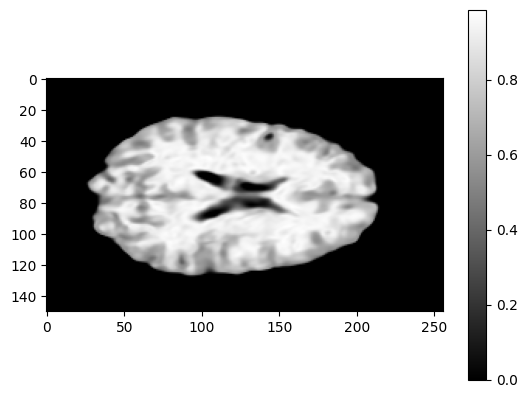

In [11]:
# model_loc = './saved_models/sens_models/' + 'sens_1.1.onnx'
model_loc = '/its/home/pi58/projects/hulfsynth/hulfsynth/saved_models/sens_models/sens_5.1.onnx'
inference_session = get_session(model_loc)
predictions, pred_seg = sample_at_resolution(inference_session)
plt.imshow((norm(predictions)[:,:,slice_num]),cmap='gray')
# plt.imshow(((pred_seg)[2,:,:,175]),cmap='gray')
# plt.gca().invert_yaxis()
plt.colorbar()
plt.show()

Segmentation Visualizations

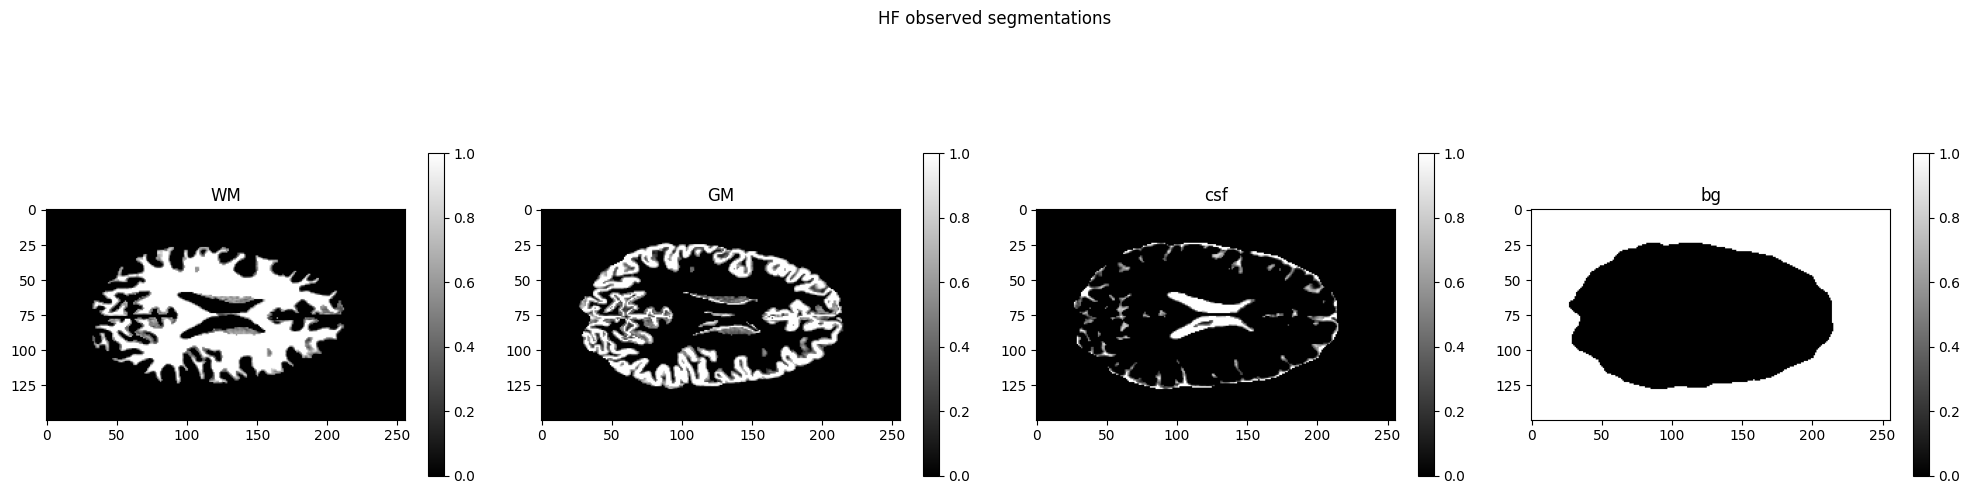

In [43]:
(wm_gt_seg, gm_gt_seg, csf_gt_seg, bg_gt_seg) = get_hf_observed_segmentations(dataset_num, config)
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
fig = plot_4_images(wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num], bg_gt_seg[:,:,slice_num], title1="WM", title2="GM", title3="csf", title4="bg")
fig.suptitle('HF observed segmentations')
fig.tight_layout()
plt.show()

In [44]:
def plot_8_images_2rows(images, titles=None, figsize=(16, 8), cmap='gray', suptitle=None, row_labels=None, save_path=None, dpi=100):
    """
    Plot 8 images in 2 rows (4 images per row) using matplotlib.
    
    Parameters:
    -----------
    images : list or array-like
        List of 8 images to plot. Each image should be a numpy array.
        Can be 2D (grayscale) or 3D (RGB/color) arrays.
        Images 0-3 go in first row, images 4-7 go in second row.
    titles : list, optional
        List of 8 titles for each subplot. Default is None.
    figsize : tuple, optional
        Figure size as (width, height). Default is (16, 8).
    cmap : str, optional
        Colormap for grayscale images. Default is 'gray'.
    suptitle : str, optional
        Overall title for the entire figure. Default is None.
    row_labels : list, optional
        List of 2 labels for each row (appears on left side). Default is None.
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    dpi : int, optional
        DPI for saved figure. Default is 100.
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects (2x4 array)
    
    Example:
    --------
    # With 8 random images
    images = [np.random.rand(100, 100) for _ in range(8)]
    titles = [f'Image {i+1}' for i in range(8)]
    plot_8_images_2rows(images, titles=titles, suptitle='8 Sample Images')
    plt.show()
    """
    
    if len(images) != 8:
        raise ValueError("Exactly 8 images must be provided")
    
    # Create figure and subplots (2 rows, 4 columns)
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    
    # Set overall title if provided
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=0.98)
    
    # Plot images
    for i, img in enumerate(images):
        row_idx = i // 4  # Row index (0 or 1)
        col_idx = i % 4   # Column index (0, 1, 2, or 3)
        ax = axes[row_idx, col_idx]
        
        # Handle different image formats
        if len(img.shape) == 2:  # Grayscale
            im = ax.imshow(img, cmap=cmap)
        elif len(img.shape) == 3:  # Color
            if img.shape[2] == 1:  # Single channel
                im = ax.imshow(img.squeeze(), cmap=cmap)
            else:  # RGB/RGBA
                im = ax.imshow(img)
        else:
            raise ValueError(f"Image {i} has unsupported shape: {img.shape}")
        
        # Set title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=12, pad=10)
        
        # Remove axes ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add row labels on the leftmost column
        if col_idx == 0 and row_labels and row_idx < len(row_labels):
            ax.set_ylabel(row_labels[row_idx], fontsize=9, color='blue',
                         rotation=90, labelpad=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, axes

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'BG'}, ylabel='observed (slice: 175)'>,
         <Axes: title={'center': 'WM'}>, <Axes: title={'center': 'GM'}>,
         <Axes: title={'center': 'CSF'}>],
        [<Axes: ylabel='predicted (slice: 175)'>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

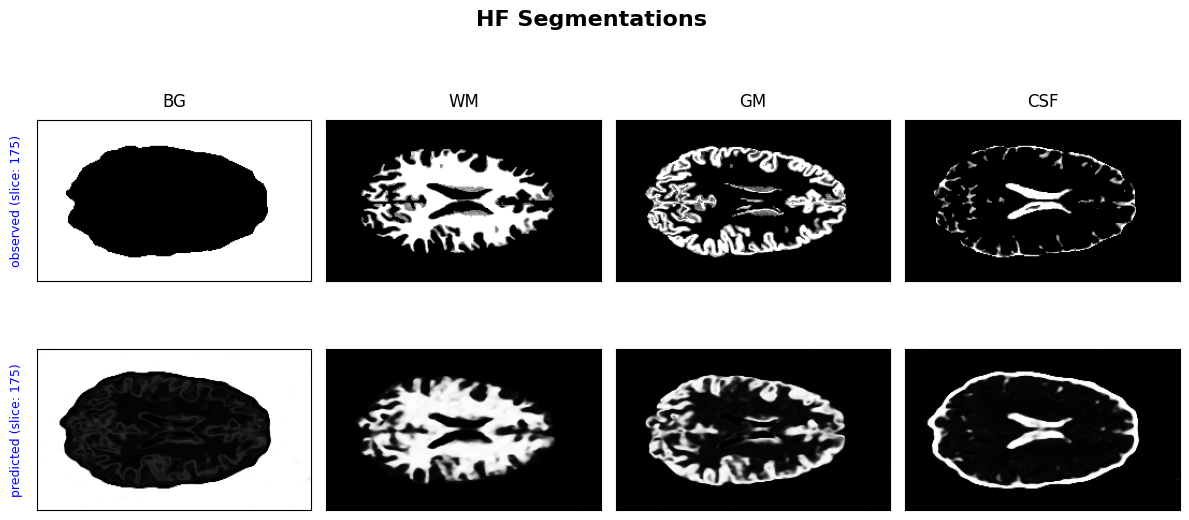

In [45]:
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,slice_num], pred_seg[1,:,:,slice_num], pred_seg[2,:,:,slice_num], pred_seg[3,:,:,slice_num]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='HF Segmentations ', row_labels=['observed' +' (slice: ' + str(slice_num) +')', 'predicted '+ '(slice: ' + str(slice_num) +')'], save_path=None, dpi=100)

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'BG'}, ylabel='observed (slice: 176)'>,
         <Axes: title={'center': 'WM'}>, <Axes: title={'center': 'GM'}>,
         <Axes: title={'center': 'CSF'}>],
        [<Axes: ylabel='predicted(slice: 176)'>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

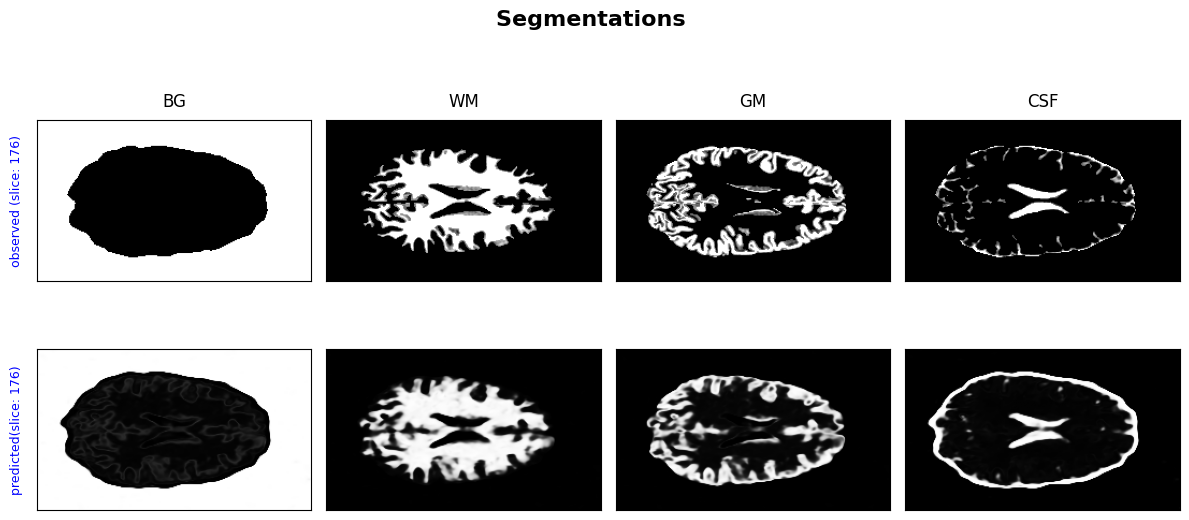

In [46]:
other_slice = slice_num + 1
images_gt = [bg_gt_seg[:,:,other_slice], wm_gt_seg[:,:,other_slice], gm_gt_seg[:,:,other_slice], csf_gt_seg[:,:,other_slice]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,other_slice], pred_seg[1,:,:,other_slice], pred_seg[2,:,:,other_slice], pred_seg[3,:,:,other_slice]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='Segmentations ', row_labels=['observed' +' (slice: ' + str(other_slice) +')', 'predicted'+ '(slice: ' + str(other_slice) +')'], save_path=None, dpi=100)

In [47]:
def plot_3_images_row(images, titles=None, figsize=(12, 4), cmap='gray',  suptitle=None, save_path=None, dpi=100, show_colorbar=False):
    """
    Plot 3 images in a single row using matplotlib.
    
    Parameters:
    -----------
    images : list or array-like
        List of 3 images to plot. Each image should be a numpy array.
        Can be 2D (grayscale) or 3D (RGB/color) arrays.
    titles : list, optional
        List of 3 titles for each subplot. Default is None.
    figsize : tuple, optional
        Figure size as (width, height). Default is (12, 4).
    cmap : str, optional
        Colormap for grayscale images. Default is 'gray'.
    suptitle : str, optional
        Overall title for the entire figure. Default is None.
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    dpi : int, optional
        DPI for saved figure. Default is 100.
    show_colorbar : bool, optional
        Whether to show colorbar for grayscale images. Default is False.
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    
    Example:
    --------
    # With random images
    images = [np.random.rand(100, 100) for _ in range(3)]
    titles = ['Original', 'Processed', 'Result']
    plot_3_images_row(images, titles=titles, suptitle='Image Processing Pipeline')
    plt.show()
    """
    
    if len(images) != 3:
        raise ValueError("Exactly 3 images must be provided")
    
    # Create figure and subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Set overall title if provided
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.02)
    
    # Plot each image
    for i, (ax, img) in enumerate(zip(axes, images)):
        # Handle different image formats
        if len(img.shape) == 2:  # Grayscale
            im = ax.imshow(img, cmap=cmap)
            if show_colorbar:
                plt.colorbar(im, ax=ax, shrink=0.8)
        elif len(img.shape) == 3:  # Color
            if img.shape[2] == 1:  # Single channel
                im = ax.imshow(img.squeeze(), cmap=cmap)
                if show_colorbar:
                    plt.colorbar(im, ax=ax, shrink=0.8)
            else:  # RGB/RGBA
                im = ax.imshow(img)
        else:
            raise ValueError(f"Image {i} has unsupported shape: {img.shape}")
        
        # Set title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=12, pad=10, color = 'blue')
        
        # Remove axes ticks
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, axes

(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: title={'center': 'observed'}>,
        <Axes: title={'center': 'predicted'}>,
        <Axes: title={'center': 'predicted (weighted sum)'}>], dtype=object))

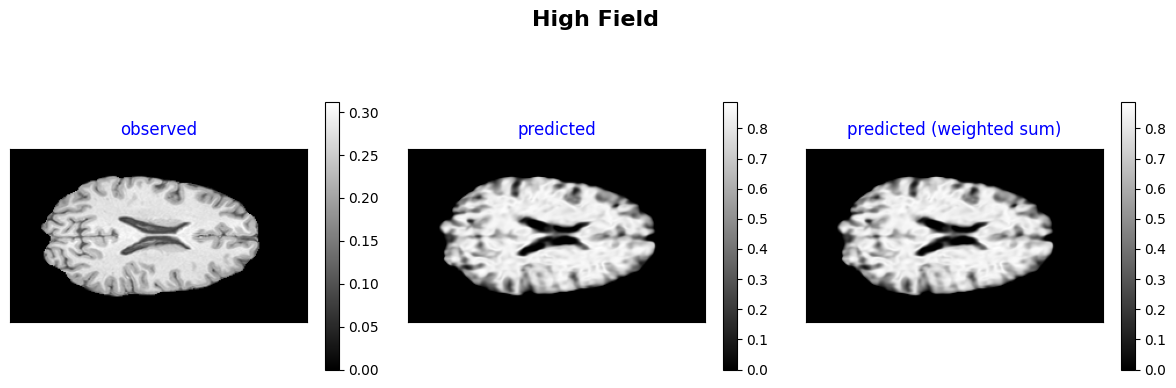

In [57]:
final_img = (predictions * pred_seg[1]) + (predictions * pred_seg[2]) + (predictions * pred_seg[3]) + (predictions * pred_seg[0])
# plt.imshow(final_img[:,:,95], cmap='gray')

images = [norm(torch.from_numpy(hf_ground_truth))[:,:,slice_num] , (predictions)[:,:,slice_num], (final_img)[:,:,slice_num]]
# images2 = [norm(predictions * pred_seg[0])[:,:,slice_num] , norm((predictions * pred_seg[2]))[:,:,slice_num], norm((predictions * pred_seg[3]))[:,:,slice_num]]
titles = ['observed', 'predicted', 'predicted (weighted sum)']
plot_3_images_row(images, titles=titles, figsize=(12, 4), cmap='gray',  suptitle='High Field', save_path=None, dpi=100, show_colorbar=True)

Segmentation Scores

In [50]:
dice_score = monai.metrics.DiceMetric()
dice2 = monai.metrics.GeneralizedDiceScore()
iou_score = monai.metrics.MeanIoU()
psnr_value = monai.metrics.PSNRMetric(max_val = 1.0) #expects shape: BCHWD
ssim_value = monai.metrics.regression.SSIMMetric(spatial_dims=3, data_range=1.0) #expects shape: BCHWD

hf_gt_seg = torch.from_numpy(np.stack((bg_gt_seg, wm_gt_seg, gm_gt_seg, csf_gt_seg), axis = 0))


print("Dice (mean): ", dice_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print("Dice (generalized): ", dice2(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0).to(torch.float32)).mean())
print("IoU (mean): ", iou_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print("\n \n Scores of predictions")
print('psnr (norm): ', psnr_value( torch.from_numpy(norm(predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim (norm): ', ssim_value( torch.from_numpy(norm(predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('psnr : ', psnr_value( torch.from_numpy((predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim : ', ssim_value( torch.from_numpy((predictions)).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))

Dice (mean):  tensor(0.3122, dtype=torch.float64)
Dice (generalized):  tensor(0.5397)
IoU (mean):  tensor(0.5566, dtype=torch.float64)

 
 Scores of predictions
psnr (norm):  tensor([[13.1326]], dtype=torch.float64)
ssim (norm):  tensor([[0.8153]])
psnr :  tensor([[14.5561]], dtype=torch.float64)
ssim :  tensor([[0.8254]])


In [56]:
temp = norm(predictions)
final_img = ((temp * pred_seg[1]) + (temp * pred_seg[2]) + (temp * pred_seg[3])) #+ (predictions * pred_seg[0]))
print('psnr: ', psnr_value( torch.from_numpy(final_img).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim: ', ssim_value( torch.from_numpy(final_img).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))

psnr:  tensor([[13.9844]], dtype=torch.float64)
ssim:  tensor([[0.8197]])


Final Image (multiple views)

In [ ]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data = final_img
dims = data.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice = data[:, 200, :]
axes[0].imshow(coronal_slice, cmap='gray')
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice = data[75, :, :]
axes[1].imshow(sagittal_slice, cmap='gray')
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice_index = 175
axial_slice = data[:, :, axial_slice_index]
axes[2].imshow(axial_slice, cmap='gray')
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()

plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.patches as mpatches

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data1 = pred_seg[1]
data2 = pred_seg[2]
data3 = pred_seg[3]
dims = data1.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice1 = data1[:, coronal_slice_index, :].T
coronal_slice2 = data2[:, coronal_slice_index, :].T
coronal_slice3 = data3[:, coronal_slice_index, :].T




axes[0].imshow(coronal_slice1, cmap='Greens')
axes[0].imshow(coronal_slice2, cmap='Reds', alpha = 0.9 * coronal_slice2)
axes[0].imshow(coronal_slice3, cmap='Blues', alpha = 0.9 * coronal_slice3)
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice1 = data1[sagittal_slice_index, :, :].T
sagittal_slice2 = data2[sagittal_slice_index, :, :].T
sagittal_slice3 = data3[sagittal_slice_index, :, :].T
axes[1].imshow(sagittal_slice1, cmap='Greens', alpha = 0.9 * sagittal_slice1)
axes[1].imshow(sagittal_slice2, cmap='Reds', alpha = 0.9 * sagittal_slice2)
axes[1].imshow(sagittal_slice3, cmap='Blues', alpha = 0.9 * sagittal_slice3)
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice1 = data1[:, :, axial_slice_index].T
axial_slice2 = data2[:, :, axial_slice_index].T
axial_slice3 = data3[:, :, axial_slice_index].T

axes[2].imshow(axial_slice1, cmap='Greens', alpha = 0.9 * axial_slice1)
axes[2].imshow(axial_slice2, cmap='Reds', alpha = 0.9 * axial_slice2)
axes[2].imshow(axial_slice3, cmap='Blues', alpha = 0.9 * axial_slice3)
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()


fig.suptitle("Segmentations (pve)", color='blue')
green_patch = mpatches.Patch(color='green', alpha=0.9, label='CSF')
red_patch = mpatches.Patch(color='red', alpha=0.9, label='GM')
blue_patch = mpatches.Patch(color='blue', alpha=0.9, label='CSF')

fig.legend(handles=[red_patch, blue_patch, green_patch])#, loc='lower right')
# fig.legend(handles=[red_patch, blue_patch], loc='center', fontsize=12)


plt.tight_layout()
plt.show()

Sensitivity results

In [17]:
#Download all models
'''
import wandb
run = wandb.init()
artifact = run.use_artifact('pi58-sussex/hulfsynth/model:v257', type='model')
artifact_dir = artifact.download()
artifact = run.use_artifact('pi58-sussex/hulfsynth/model:v258', type='model')
artifact_dir = artifact.download()
'''

"\nimport wandb\nrun = wandb.init()\nartifact = run.use_artifact('pi58-sussex/hulfsynth/model:v257', type='model')\nartifact_dir = artifact.download()\nartifact = run.use_artifact('pi58-sussex/hulfsynth/model:v258', type='model')\nartifact_dir = artifact.download()\n"

In [ ]:
lf_gt_list = []
for i in range(1,6):
    _, lf_gt, _, M = load_sensitivity_data(dataset_num, config, sens_id=i)
    print("ID: ", i, "M: ", M)
    lf_gt_list.append(lf_gt)

def plot_5_images(img1, img2, img3, img4, img5, title1="img1", title2="img2", title3="img3", title4="img4", title5="img5"):

    fig, axes = plt.subplots(1,5, figsize=(20,6))
    im1 = axes[0].imshow(img1, cmap = 'gray', vmax=0.8)
    im2 = axes[1].imshow(img2, cmap = 'gray', vmax=0.8)
    im3 = axes[2].imshow(img3, cmap = 'gray', vmax=0.8)
    im4 = axes[3].imshow(img4, cmap = 'gray', vmax=0.8)
    im5 = axes[4].imshow(img5, cmap = 'gray', vmax=0.8)
    # im6 = axes[4].imshow(img5, cmap='Reds' ,alpha= 0.9*(condition))
    shrink_val = 0.25
    fig.colorbar(im1, shrink = shrink_val)
    fig.colorbar(im2, shrink = shrink_val)
    fig.colorbar(im3, shrink = shrink_val)
    fig.colorbar(im4, shrink = shrink_val)
    fig.colorbar(im5, shrink = shrink_val)
    # fig.colorbar(im6, shrink = 0.4)

    axes[0].set_title(title1)
    axes[1].set_title(title2)
    axes[2].set_title(title3)
    axes[3].set_title(title4)
    axes[4].set_title(title5)
    [axes[i].set_axis_off() for i in range(5)]
    # plt.show(block=False)
    return fig

fig_sens = plot_5_images(lf_gt_list[0][:,:,slice_num], lf_gt_list[1][:,:,slice_num], lf_gt_list[2][:,:,slice_num], lf_gt_list[3][:,:,slice_num], lf_gt_list[4][:,:,slice_num], 
title1="c1", title2="c2", title3="c3", title4="c4", title5="c5")


In [68]:
model_list = ['sens_1.1.onnx', 'sens_2.1.onnx', 'sens_3.1.onnx', 'sens_4.1.onnx', 'sens_5.1.onnx']
pred_list = []
pred_seg_list = []
lf_gt_list = []
M_list = []
lf_gt_seg_dice_list = []
for i in range(len(model_list)):
    model_loc = './saved_models/sens_models/' + model_list[i]
    inference_session = get_session(model_loc)
    pred, pred_seg = sample_at_resolution(inference_session)
    _, lf_gt, lf_gt_seg_dice, M = load_sensitivity_data(dataset_num, config, sens_id=i+1)
    pred_list.append(pred)
    pred_seg_list.append(pred_seg)
    lf_gt_list.append(lf_gt)
    lf_gt_seg_dice_list.append(lf_gt_seg_dice)
    M_list.append(M)
    print('Inference for model', model_list[i], 'complete')

2025-10-12 10:04:44.244231786 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-12 10:04:44.276894313 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-12 10:04:44.310241158 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-12 10:04:44.348543870 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


[0.5764403917464679, 0.6112914959606284, 0.29652244846263903]
Inference for model sens_1.1.onnx complete


2025-10-12 10:05:07.741325785 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-12 10:05:07.775008693 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-12 10:05:07.810391502 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-12 10:05:07.839495317 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


[0.38706167679243647, 0.4091320800323135, 0.46722225082056074]
Inference for model sens_2.1.onnx complete


2025-10-12 10:05:29.767366459 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-12 10:05:29.804295206 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-12 10:05:29.844888734 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-12 10:05:29.865257249 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


[0.3750057510478516, 0.4159299494828761, 0.40871221039940486]
Inference for model sens_3.1.onnx complete


2025-10-12 10:05:53.017887898 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-12 10:05:53.061498331 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-12 10:05:53.096478475 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-12 10:05:53.123694839 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


[0.2922862863632516, 0.2914280646044458, 0.13082497107286503]
Inference for model sens_4.1.onnx complete


2025-10-12 10:06:15.266785230 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output input.3
2025-10-12 10:06:15.306427108 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {9830400,4} for output 48
2025-10-12 10:06:15.348685735 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output input
2025-10-12 10:06:15.369727198 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {9830400} for output 47


[0.44941831294921486, 0.47782133231130053, 0.23299362575949675]
Inference for model sens_5.1.onnx complete


In [115]:
norm_pred_list = []
final_img_list = []
ulf_residual_list = []
pred_ulf_list = []
for i in range(5):
    norm_pred = norm(pred_list[i])
    final_img = (norm_pred * pred_seg_list[i][1]) + (norm_pred * pred_seg_list[i][2]) + (norm_pred * pred_seg_list[i][3]) #+ (temp_pred * pred_seg[3])
    pred_ulf = contrast_modulation(pred_seg, final_img, config) #try with pred_img, norm_pred
    residual = np.abs(pred_ulf - lf_gt_list[i])
    
    final_img_list.append(final_img)
    norm_pred_list.append(norm_pred)
    pred_ulf_list.append(pred_ulf)
    ulf_residual_list.append(residual)
    
final_img_list = torch.tensor(final_img_list)
norm_pred_list =  torch.tensor(norm_pred_list)
ulf_residual_list = torch.tensor(ulf_residual_list)
pred_ulf_list = torch.tensor(pred_ulf_list)

### visualize final images

In [120]:

def plot_images_in_row(images: List[np.ndarray], titles: Optional[List[str]] = None, sup_title: Optional=None , vmax_list:Optional=None, cmap: str = 'gray', figsize: tuple = (15, 4)):
    """
    Plots a list of images in a single row using Matplotlib.

    Args:
        images (List[np.ndarray]): A list of NumPy arrays representing the images.
                                   (e.g., [img1, img2, img3])
        titles (Optional[List[str]]): An optional list of titles for each image.
                                      If provided, the length must match the number of images.
        cmap (str): The colormap to use for displaying the images. Default is 'gray'.
        figsize (tuple): The overall size of the figure. Default is (15, 4).
    """
    num_images = len(images)
    
    # 1. Input Validation
    if not 1 <= num_images <= 5:
        print(f"Warning: This function is optimized for 1 to 5 images. Received {num_images}.")
        # Continue execution even if the limit is exceeded, but warn the user.
        
    if titles is not None and len(titles) != num_images:
        raise ValueError(f"The number of titles ({len(titles)}) must match the number of images ({num_images}).")

    # 2. Create the Figure and Subplots (1 row, N columns)
    # The `squeeze=False` ensures that `axes` is always a 2D array, even if num_images=1, 
    # making the indexing consistent.

    vmax = 1.0
    fig, axes = plt.subplots(1, num_images, figsize=figsize, squeeze=False)
    
    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    # 3. Plot Each Image
    for i in range(num_images):
        ax = axes[i]
        img = images[i]
        
        if(vmax_list):
            vmax = vmax_list[i]
        im = ax.imshow(img, cmap=cmap, vmax=vmax)
        fig.colorbar(im, orientation='vertical',shrink=0.75)

        
        # Apply title if available
        if titles is not None:
            ax.set_title(titles[i], fontsize=10)
        
        # Remove axis ticks and labels for cleaner image display
        ax.axis('off')

    # Adjust layout to prevent titles and images from overlapping
    if(sup_title):
        fig.suptitle(sup_title)
    plt.tight_layout()
    plt.show()



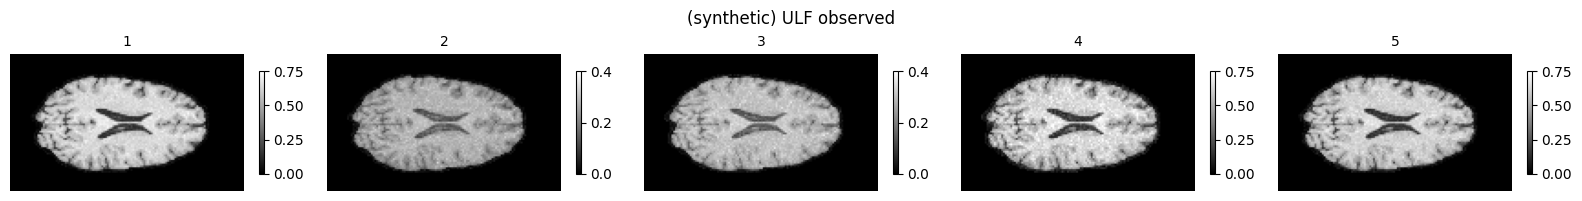

In [123]:
temp_list = [lf_gt_list[0][:,:,slice_num], lf_gt_list[1][:,:,slice_num], lf_gt_list[2][:,:,slice_num], lf_gt_list[3][:,:,slice_num], lf_gt_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "(synthetic) ULF observed",
    vmax_list = [0.75, 0.4, 0.4, 0.75, 0.75],
    cmap='gray',
    figsize=(16, 2) # Smaller figure size for fewer images
)

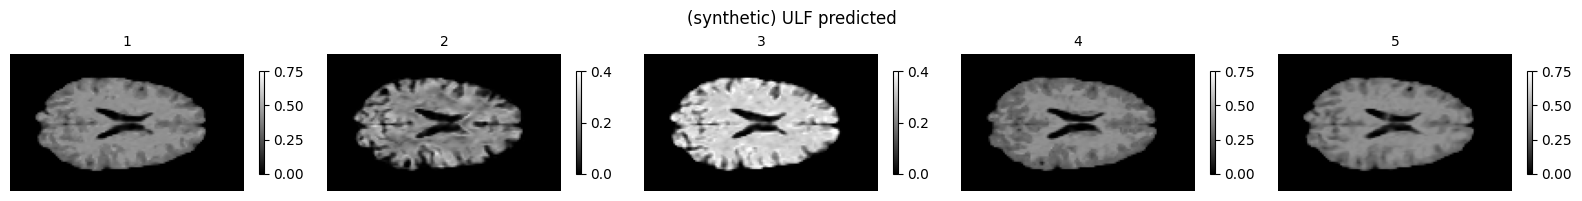

In [124]:
# temp_list = [final_img_list[0][:,:,slice_num], final_img_list[1][:,:,slice_num], final_img_list[2][:,:,slice_num], final_img_list[3][:,:,slice_num], final_img_list[4][:,:,slice_num]]
temp_list = [pred_ulf_list[0][:,:,slice_num], pred_ulf_list[1][:,:,slice_num], pred_ulf_list[2][:,:,slice_num], pred_ulf_list[3][:,:,slice_num], pred_ulf_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "ULF predicted",
    vmax_list = [0.75, 0.4, 0.4, 0.75, 0.75],
    cmap='gray',
    figsize=(16, 2) # Smaller figure size for fewer images
)

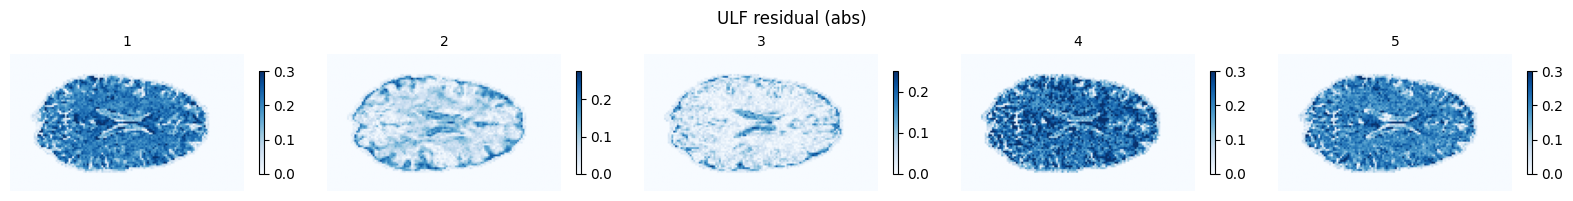

In [130]:
# temp_list = [final_img_list[0][:,:,slice_num], final_img_list[1][:,:,slice_num], final_img_list[2][:,:,slice_num], final_img_list[3][:,:,slice_num], final_img_list[4][:,:,slice_num]]
temp_list = [ulf_residual_list[0][:,:,slice_num], ulf_residual_list[1][:,:,slice_num], ulf_residual_list[2][:,:,slice_num], ulf_residual_list[3][:,:,slice_num], ulf_residual_list[4][:,:,slice_num]]
plot_images_in_row(
    images=temp_list,
    titles=['1', '2', '3', '4', '5',],
    sup_title = "ULF residual (abs)",
    vmax_list = [0.3, 0.275, 0.25, 0.3, 0.3],
    cmap='Blues',
    figsize=(16, 2) # Smaller figure size for fewer images
)

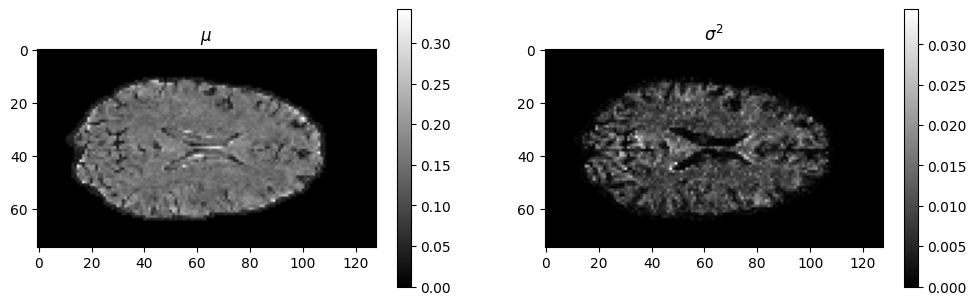

In [133]:
(sigma_ulf_residual, mu_ulf_residual) = torch.std_mean(ulf_residual_list, dim =0)
f2 = plot_2_images(mu_ulf_residual[:,:,slice_num], (sigma_ulf_residual**2)[:,:, slice_num], title1='$\\mu$', title2='$\\sigma^2$')

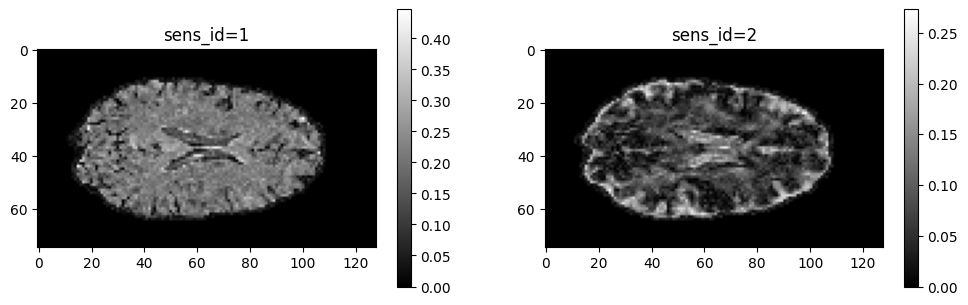

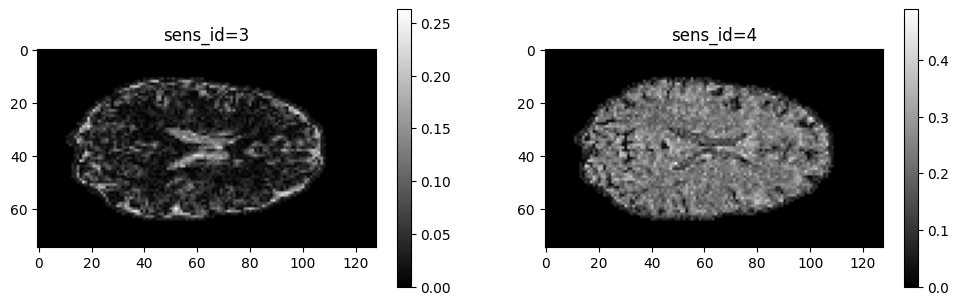

In [132]:
f4 = plot_2_images(ulf_residual_list[0][:,:,175], ulf_residual_list[1][:,:,175], title1='sens_id=1', title2='sens_id=2')
f5 = plot_2_images(ulf_residual_list[2][:,:,175], ulf_residual_list[3][:,:,175], title1='sens_id=3', title2='sens_id=4')

In [ ]:
from deepinv.utils.demo import load_example
from deepinv.loss.metric import LPIPS, HaarPSI
import nibabel as nib
import torch

x1 = torch.from_numpy(nib.load('./Data/ixi/T1/102/sensitivity_data/contrast/4/brain.nii.gz').get_fdata()).to(torch.float32) #[:,:,175] #.unsqueeze(0).unsqueeze(0).to(torch.float32)
x2 = torch.from_numpy(nib.load("./Data/ixi/T1/102/sensitivity_data/contrast/5/brain.nii.gz").get_fdata()).to(torch.float32) #[:,:,175] #.unsqueeze(0).unsqueeze(0).to(torch.float32)

lpips = LPIPS()
haar = HaarPSI(norm_inputs="clip")
z1 = lpips(x1.unsqueeze(0).permute(3,0,1,2)[30:-30], x2.unsqueeze(0).permute(3,0,1,2)[30:-30]) #removing first 30 slices and last 30 slices
z2 = haar(x1.unsqueeze(0).permute(3,0,1,2)[30:-30], x2.unsqueeze(0).permute(3,0,1,2)[30:-30])
print(z1, z2, type(z1), type(z2))
lpips_scores = torch.tensor(lpips_scores)
haar_scores = torch.tensor(haar_scores)
print(torch.median(lpips_scores), torch.mean(lpips_scores))
print(torch.median(haar_scores), torch.mean(haar_scores))

In [14]:

slice_num = 175
lpips_scores = lpips(x1.unsqueeze(0).permute(3,0,1,2)[slice_num-5:slice_num+5], x2.unsqueeze(0).permute(3,0,1,2)[slice_num-5:slice_num+5]) #computing score for middle 10 slices
haar_scores = haar(x1.unsqueeze(0).permute(3,0,1,2)[slice_num-5:slice_num+5], x2.unsqueeze(0).permute(3,0,1,2)[slice_num-5:slice_num+5])
print(torch.median(lpips_scores), torch.mean(lpips_scores))
print(torch.median(haar_scores), torch.mean(haar_scores))

tensor(0.0135) tensor(0.0151)
tensor(0.9941) tensor(0.9932)


In [13]:
lpips_scores.median()

tensor(0.0135)